In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.append("../src")

from model import SimpleCNN

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

data_dir = "../data/chest_xray"
batch_size = 1

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_dataset = datasets.ImageFolder(
    root=f"{data_dir}/test",
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Classes:", test_dataset.classes)
print("Test images:", len(test_dataset))

cpu
Classes: ['NORMAL', 'PNEUMONIA']
Test images: 624


In [4]:
model = SimpleCNN().to(device)

model.load_state_dict(
    torch.load("../outputs/models/baseline_cnn.pth", map_location=device)
)

model.eval()

print("Model loaded successfully")

Model loaded successfully


In [5]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, image, class_index):
        self.model.zero_grad()

        output = self.model(image)
        score = output[:, class_index]

        score.backward()

        gradients = self.gradients
        activations = self.activations

        weights = gradients.mean(dim=(2, 3), keepdim=True)

        cam = (weights * activations).sum(dim=1)
        cam = torch.relu(cam)

        cam = cam.squeeze()
        cam = cam.detach().cpu().numpy()

        cam = cam - cam.min()
        cam = cam / cam.max()

        return cam

In [6]:
gradcam = GradCAM(model, model.conv3)

In [7]:
image, label = test_dataset[0]

image_batch = image.unsqueeze(0).to(device)

output = model(image_batch)
predicted_class = output.argmax(dim=1).item()

print("True label:", test_dataset.classes[label])
print("Predicted label:", test_dataset.classes[predicted_class])

True label: NORMAL
Predicted label: PNEUMONIA


In [8]:
cam = gradcam.generate(image_batch, predicted_class)

print(cam.shape)
print(cam.min(), cam.max())

(56, 56)
0.0 1.0


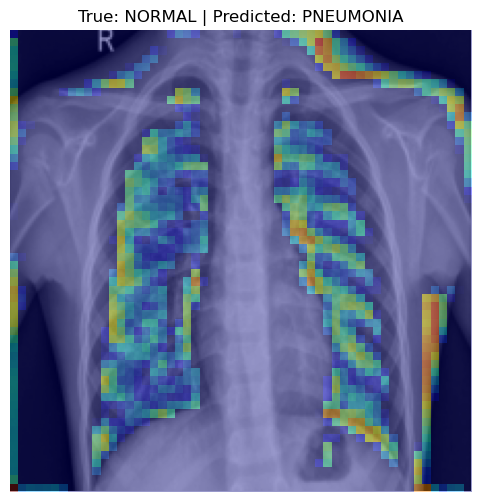

In [9]:
image_to_show = image.squeeze().numpy()

# undo normalization: original was normalized with mean=0.5, std=0.5
image_to_show = (image_to_show * 0.5) + 0.5

plt.figure(figsize=(6, 6))
plt.imshow(image_to_show, cmap="gray")
plt.imshow(cam, cmap="jet", alpha=0.4, extent=(0, 224, 224, 0))
plt.title(
    f"True: {test_dataset.classes[label]} | "
    f"Predicted: {test_dataset.classes[predicted_class]}"
)
plt.axis("off")
plt.show()

This example is a false positive: the true label is NORMAL, but the model predicts PNEUMONIA. The Grad-CAM heatmap highlights parts of the lung fields, but also activates strongly around the image borders and shoulder/non-lung regions. This suggests that the baseline CNN may be using visual shortcuts or dataset artifacts rather than relying exclusively on clinically relevant lung regions.

In [10]:
def get_prediction_for_index(index):
    image, label = test_dataset[index]
    image_batch = image.unsqueeze(0).to(device)

    output = model(image_batch)
    predicted_class = output.argmax(dim=1).item()

    return image, label, predicted_class


correct_normal = []
correct_pneumonia = []
false_positive = []  # NORMAL predicted as PNEUMONIA
false_negative = []  # PNEUMONIA predicted as NORMAL

for index in range(len(test_dataset)):
    image, label, predicted_class = get_prediction_for_index(index)

    true_name = test_dataset.classes[label]
    pred_name = test_dataset.classes[predicted_class]

    if true_name == "NORMAL" and pred_name == "NORMAL":
        correct_normal.append(index)
    elif true_name == "PNEUMONIA" and pred_name == "PNEUMONIA":
        correct_pneumonia.append(index)
    elif true_name == "NORMAL" and pred_name == "PNEUMONIA":
        false_positive.append(index)
    elif true_name == "PNEUMONIA" and pred_name == "NORMAL":
        false_negative.append(index)

print("Correct NORMAL:", len(correct_normal))
print("Correct PNEUMONIA:", len(correct_pneumonia))
print("False positives:", len(false_positive))
print("False negatives:", len(false_negative))

Correct NORMAL: 61
Correct PNEUMONIA: 388
False positives: 173
False negatives: 2


In [12]:
def show_gradcam_for_index(index):
    image, label = test_dataset[index]
    image_batch = image.unsqueeze(0).to(device)

    output = model(image_batch)
    predicted_class = output.argmax(dim=1).item()

    cam = gradcam.generate(image_batch, predicted_class)

    image_to_show = image.squeeze().numpy()
    image_to_show = (image_to_show * 0.5) + 0.5  # undo normalization

    true_name = test_dataset.classes[label]
    pred_name = test_dataset.classes[predicted_class]

    plt.figure(figsize=(6, 6))
    plt.imshow(image_to_show, cmap="gray")
    plt.imshow(cam, cmap="jet", alpha=0.4, extent=(0, 224, 224, 0))
    plt.title(f"True: {true_name} | Predicted: {pred_name}")
    plt.axis("off")
    plt.show()

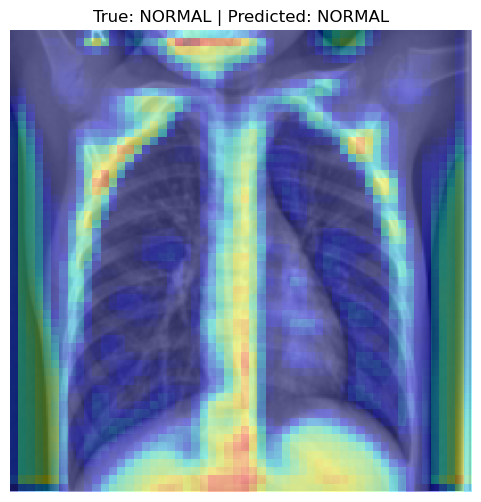

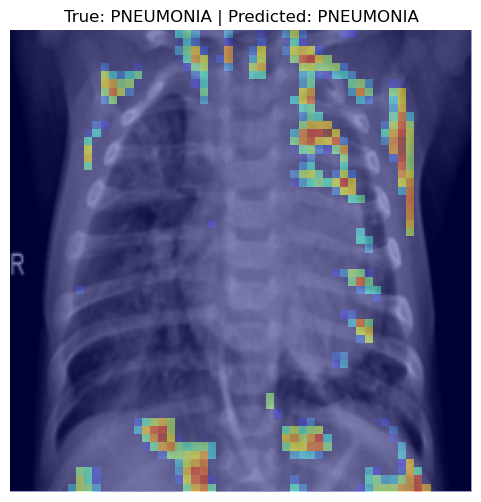

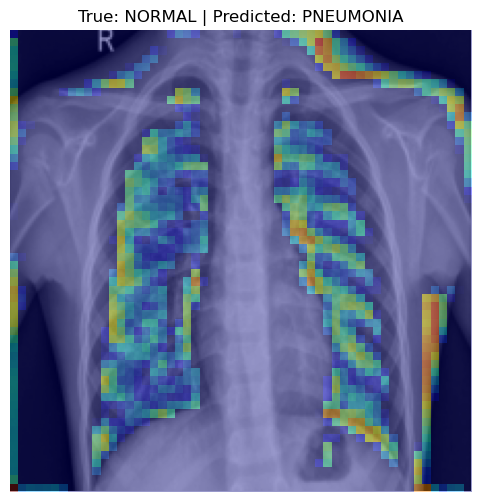

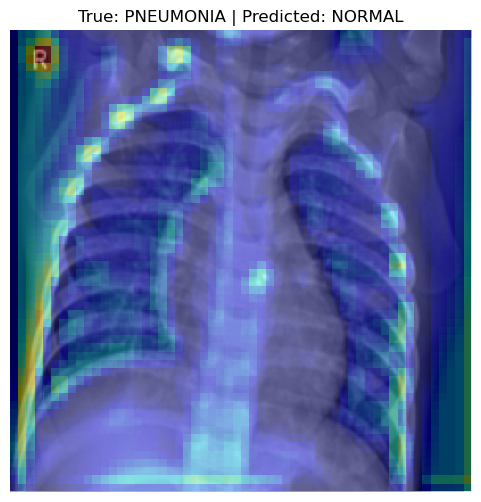

In [13]:
show_gradcam_for_index(correct_normal[0])
show_gradcam_for_index(correct_pneumonia[0])
show_gradcam_for_index(false_positive[0])

if len(false_negative) > 0:
    show_gradcam_for_index(false_negative[0])
else:
    print("No false negative example available.")

## Grad-CAM observations

The Grad-CAM visualizations show that the baseline CNN does not consistently focus only on lung fields. Some highlighted regions overlap with the lungs, but several examples also show strong activation near image borders, shoulders, the spine, and lower image edges.

This is especially relevant because the model strongly overpredicts PNEUMONIA on the test set. In false-positive cases, where the true label is NORMAL but the model predicts PNEUMONIA, the heatmap includes both lung regions and non-lung regions. This suggests that the model may be relying on visual shortcuts or dataset-specific artifacts rather than purely clinically meaningful evidence.

These results motivate treating the CNN as a baseline model rather than a reliable diagnostic system.

In [14]:
import os

os.makedirs("../outputs/figures", exist_ok=True)

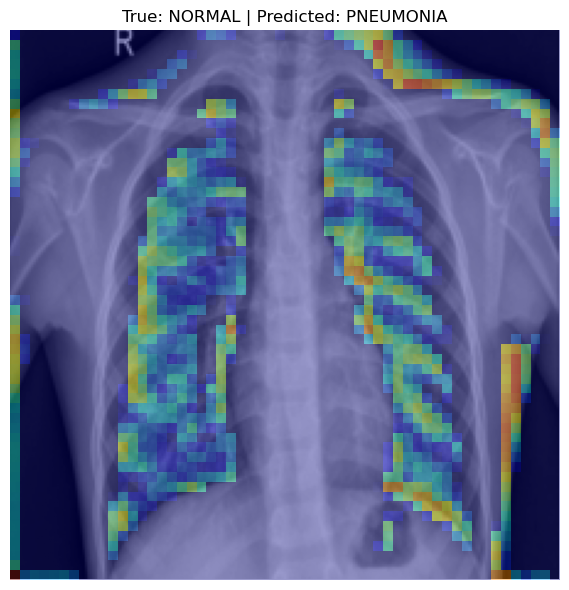

In [18]:
def save_gradcam_for_index(index, filename):
    image, label = test_dataset[index]
    image_batch = image.unsqueeze(0).to(device)

    output = model(image_batch)
    predicted_class = output.argmax(dim=1).item()

    cam = gradcam.generate(image_batch, predicted_class)

    image_to_show = image.squeeze().numpy()
    image_to_show = (image_to_show * 0.5) + 0.5

    true_name = test_dataset.classes[label]
    pred_name = test_dataset.classes[predicted_class]

    plt.figure(figsize=(6, 6))
    plt.imshow(image_to_show, cmap="gray")
    plt.imshow(cam, cmap="jet", alpha=0.4, extent=(0, 224, 224, 0))
    plt.title(f"True: {true_name} | Predicted: {pred_name}")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"../outputs/figures/{filename}", dpi=300, bbox_inches="tight")
    plt.show()

save_gradcam_for_index(false_positive[0], "gradcam_false_positive.png")